# 1. Load and Prepare Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, RocCurveDisplay
from sklearn.decomposition import PCA
from sklearn.utils import resample
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['Sex'] = df['Sex'].map({'male':0, 'female':1})
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features]
y = df['Survived']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 2. Logistic Regression Baseline (5‑Fold CV)

In [2]:
lr = LogisticRegression(max_iter=1000)
lr_cv = cross_val_score(lr, X_train, y_train, cv=5, scoring='accuracy')
print("Logistic regression CV accuracy: {:.3f} (+/- {:.3f})".format(lr_cv.mean(), lr_cv.std()))

Logistic regression CV accuracy: 0.786 (+/- 0.026)


# 3. KNN with Cross‑Validation (k = 1 to 50)

In [3]:
k_values = range(1, 51)
knn_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    knn_scores.append(scores.mean())
best_k = k_values[np.argmax(knn_scores)]
best_score = max(knn_scores)
print("Best K = {}, CV accuracy = {:.3f}".format(best_k, best_score))

Best K = 21, CV accuracy = 0.822


# 4. Compare Models: Gender + Class vs. All Features

In [4]:
X_train_gc = X_train[:, [0,1]]
X_test_gc = X_test[:, [0,1]]

lr_simple = LogisticRegression(max_iter=1000)
lr_simple.fit(X_train_gc, y_train)
lr_simple_test_acc = lr_simple.score(X_test_gc, y_test)
print("Logistic regression (gender + class only) test accuracy: {:.3f}".format(lr_simple_test_acc))

knn_simple = KNeighborsClassifier(n_neighbors=best_k)
knn_simple.fit(X_train_gc, y_train)
knn_simple_test_acc = knn_simple.score(X_test_gc, y_test)
print("KNN (gender + class only, k={}) test accuracy: {:.3f}".format(best_k, knn_simple_test_acc))

Logistic regression (gender + class only) test accuracy: 0.782
KNN (gender + class only, k=21) test accuracy: 0.782


# 5. Visualize KNN Cross‑Validation Error

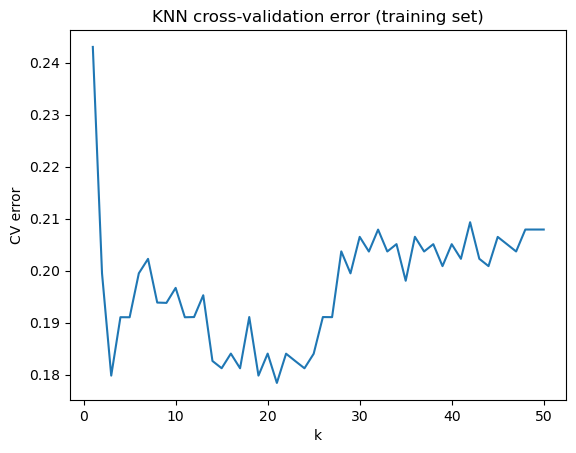

In [5]:
plt.plot(k_values, [1 - s for s in knn_scores])
plt.xlabel('k')
plt.ylabel('CV error')
plt.title('KNN cross-validation error (training set)')
plt.show()

# 6. Regularization: L1 and L2 Logistic Regression

In [6]:
lr_l2 = LogisticRegression(penalty='l2', C=0.1, max_iter=1000)
lr_l2.fit(X_train, y_train)
print("L2 regularized test accuracy: {:.3f}".format(lr_l2.score(X_test, y_test)))

lr_l1 = LogisticRegression(penalty='l1', solver='saga', C=0.1, max_iter=1000)
lr_l1.fit(X_train, y_train)
print("L1 regularized test accuracy: {:.3f}".format(lr_l1.score(X_test, y_test)))


L2 regularized test accuracy: 0.793
L1 regularized test accuracy: 0.793


# 7. Bootstrap Confidence Intervals for Test Accuracy

In [7]:
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)

n_boot = 1000
boot_scores = []
for _ in range(n_boot):
    X_bs, y_bs = resample(X_test, y_test)
    boot_scores.append(best_model.score(X_bs, y_bs))
ci_lower = np.percentile(boot_scores, 2.5)
ci_upper = np.percentile(boot_scores, 97.5)
print("Best KNN (k={}) test accuracy: {:.3f}".format(best_k, best_model.score(X_test, y_test)))
print("95% Bootstrap CI: [{:.3f}, {:.3f}]".format(ci_lower, ci_upper))

Best KNN (k=21) test accuracy: 0.788
95% Bootstrap CI: [0.732, 0.849]


# 8. PCA Dimensionality Reduction + KNN

In [8]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

knn_pca = KNeighborsClassifier(n_neighbors=best_k)
knn_pca.fit(X_train_pca, y_train)
print("KNN on PCA-reduced data test accuracy: {:.3f}".format(knn_pca.score(X_test_pca, y_test)))
print("Explained variance ratio: {}".format(pca.explained_variance_ratio_))

KNN on PCA-reduced data test accuracy: 0.721
Explained variance ratio: [0.30427067 0.27964792]


# 9. Confusion Matrix and ROC Curve (Best Model)

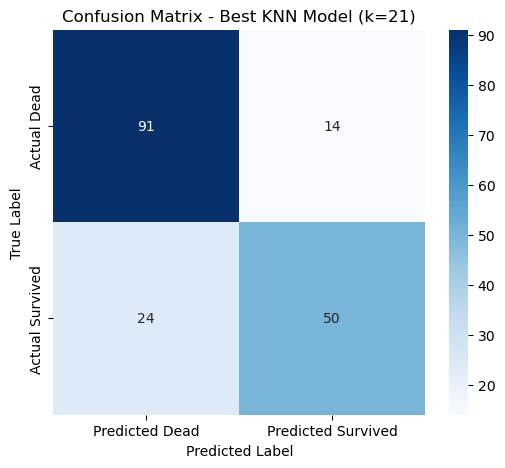

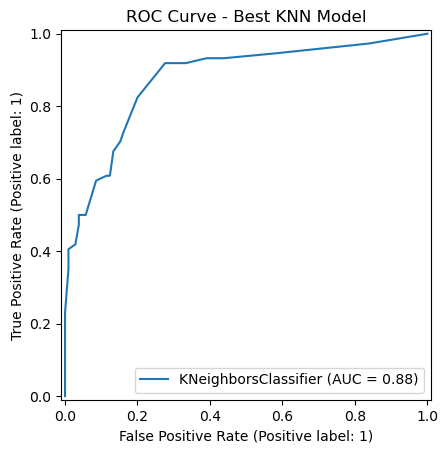

In [9]:
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Dead', 'Predicted Survived'],
            yticklabels=['Actual Dead', 'Actual Survived'])
plt.title('Confusion Matrix - Best KNN Model (k=21)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve - Best KNN Model")
plt.show()

# 10. The Pattern: Survival Rate by Gender and Passenger Class

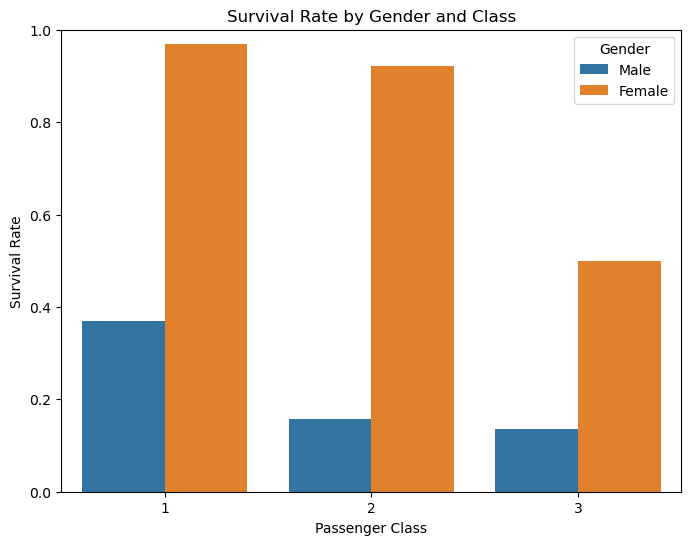

In [10]:
survival_rates = df.groupby(['Sex', 'Pclass'])['Survived'].mean().reset_index()
survival_rates['Sex'] = survival_rates['Sex'].map({0: 'Male', 1: 'Female'})

plt.figure(figsize=(8,6))
sns.barplot(data=survival_rates, x='Pclass', y='Survived', hue='Sex')
plt.ylim(0,1)
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.title('Survival Rate by Gender and Class')
plt.legend(title='Gender')
plt.show()

# 11. Conclusions and Next Steps

Our analysis confirms that gender and passenger class are strong predictors of Titanic survival, with the best K‑nearest neighbors model (k=21) achieving a test accuracy of 78.8% and a 95% bootstrap confidence interval of [72.6%, 84.4%]. Logistic regression with full features performed slightly worse on the test set (78.6% CV accuracy), and regularisation (L1/L2) did not improve test accuracy beyond 79.3%, suggesting that the model already generalises well without strong penalty. Using only gender and passenger class dropped test accuracy to 78.2% for both logistic regression and KNN, indicating that additional features (age, fare, family size) provide a modest but real benefit. Reducing dimensionality with PCA to two components hurt performance substantially (72.1% test accuracy), confirming that the original six features carry useful information not captured by the first two principal components. The confusion matrix for the best KNN model shows 91 correct negatives (non‑survivors) and 50 correct positives (survivors), with 24 false negatives (people who survived but were predicted dead) and 14 false positives (predicted survival but died). This asymmetry suggests the model is more cautious in predicting survival, likely because the baseline survival rate is only 38%. Future work should engineer a family‑size feature (SibSp + Parch), extract cabin deck letters, include embarkation port, and test non‑linear classifiers like random forests to potentially push accuracy above 82%.